# Spectrogram Explanation Analysis

This notebook computes the feature attribution statistics reported in Section 8 of the paper.
It covers two dimensions of the input spectrogram:

- **Frequency dimension** (§8.1): average saliency score per mel-frequency bin for flip examples,
  revealing whether the model relies on pitch or formant frequencies.
- **Time dimension** (§8.2): word-level attribution scores derived from forced alignment,
  revealing which source words drive gender assignment.

Section 1 also reports the pitch-region coverage statistic cited in §8.1 (the percentage of
flip examples whose top-N% salient features include at least one pitch-region feature).

## Inputs

| Name | Description | How to obtain |
|---|---|---|
| `summary_dataframe.tsv` | One row per gender term instance, with model predictions, ILM probabilities, flip thresholds, and training data term frequencies. | Output of `prepare_df_for_analysis_clean.ipynb` (`output_path`). |
| `gender_explanations.h5` | Raw (unnormalised) feature attribution heatmaps — used in Section 1 only. | Generated in step 3 of [CONTRASTIVE_SPES.md](https://github.com/hlt-mt/FBK-fairseq/blob/master/fbk_works/CONTRASTIVE_SPES.md). |
| `normalized_explanations.h5` | Normalised feature attribution heatmaps — used in Sections 2–3. | Generated by `example_explanation_clean.ipynb` (`NORMALIZED_EXPLANATIONS_H5`). |
| Gentle alignment JSONs | Per-utterance word-level forced-alignment files (Gentle format), named `<base_id>`. | Run the [Gentle forced aligner](https://github.com/lowerquality/gentle) on the MuST-SHE audio. |

## Output

- Pitch-region coverage percentage (§8.1)
- Plot of average saliency score vs. frequency bin for 1F and 1M flip examples (Figure 2 / Figure 3)
- Percentage of examples where "I" or a self-referential word is the top-scoring source word (Table 3)
- Top-10 most frequently highlighted source words (Table 4)

> **Note:** Run with a single `LANG` / `MODEL` combination at a time.
> To reproduce all panels of Figure 3, re-run for each combination.

## Imports

In [2]:
import csv
import json
import os
from typing import Dict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from examples.speech_to_text.occlusion_explanation.utils.readers import read_feature_attribution_maps_from_h5

## Configuration

Set all paths and parameters in this cell before running the notebook.

In [3]:
LANG = "it"            # one of: es, fr, it  (used for Sections 2–3)
MODEL = "transformer"  # one of: transformer, conformer  (used throughout)

# Directory of Gentle forced-alignment JSON files, one per utterance
JSON_FOLDER = "/path/to/gentle_alignments/json"

# Paths for Sections 2–3 (single language/model)
SUMMARY_TSV             = f"/path/to/summary_dataframe.tsv"
# normalized_explanations.h5 – produced by example_explanation_clean.ipynb (NORMALIZED_EXPLANATIONS_H5)
NORMALIZED_EXPLANATIONS_H5 = f"/path/to/normalized_explanations.h5"

In [4]:
# DELETE THIS
SUMMARY_TSV = f'/home/lvarellaconti/results/clean/{MODEL}/en-{LANG}/summary_dataframe.tsv'
NORMALIZED_EXPLANATIONS_H5 = f'/home/lvarellaconti/results/clean/{MODEL}/en-{LANG}/contrastive_parity/normalized_explanations.h5'
JSON_FOLDER = '/storage2/MT/dennis/gentle_mustshe/json'
try:
    explanations = read_feature_attribution_maps_from_h5(NORMALIZED_EXPLANATIONS_H5)
except Exception as e:
    GENDER_EXPLANATIONS_H5 = f'/home/lvarellaconti/results/clean/{MODEL}/en-{LANG}/contrastive_parity/gender_explanations.h5'
    explanations = read_feature_attribution_maps_from_h5(GENDER_EXPLANATIONS_H5)

## 1. Pitch Region Coverage

For every example that flips (across all three languages), binarise the raw attribution heatmap
at the example-specific flip threshold and check whether any of the retained features fall in
the pitch region (mel bins 3–12, approximately 80–350 Hz). Reports the percentage cited in §8.1.

Raw (unnormalised) explanations are used here because the binarisation threshold is derived
directly from `flip_percent`, which was computed on the raw scores.

In [ ]:
samples_with_pitch = 0
total_samples = 0

# Use lowercase `lang` to avoid overwriting the LANG configuration variable
for lang in ['es', 'fr', 'it']:
    df_lang = pd.read_csv(
        f"/path/to/en-{lang}/summary_dataframe.tsv",
        sep='\t', escapechar='\\', quoting=csv.QUOTE_NONE)
    expl_path = f"/path/to/en-{lang}/contrastive_parity/gender_explanations.h5"
    explanations_lang = read_feature_attribution_maps_from_h5(expl_path)

    for idx in df_lang[~np.isnan(df_lang.flip_percent)].index:
        total_samples += 1
        exp = explanations_lang[idx]["fbank_heatmap"]

        top_percent = df_lang.loc[idx, "flip_percent"]
        threshold = torch.quantile(exp.flatten(), 1 - top_percent / 100)
        exp[exp < threshold] = 0
        exp[exp >= threshold] = 1

        # Mel bins 3–12 cover approximately 80–350 Hz (pitch range)
        if exp[:, :, 3:13].sum() > 0:
            samples_with_pitch += 1

print(f"{samples_with_pitch} / {total_samples} "
      f"({100 * samples_with_pitch / total_samples:.1f}%) "
      f"flip examples contain at least one pitch-region feature")

1503 / 1505 (99.9%) flip examples contain at least one pitch-region feature


## 2. Frequency Dimension – Average Saliency by Frequency Bin

For the language and model set in Configuration, aggregate normalised attribution heatmaps
by max-pooling over the time dimension, then average across all flip examples separately
for feminine (1F) and masculine (1M) terms. Produces Figure 2 (or one panel of Figure 3).

In [8]:
def mel_to_hertz(mel):
    """Convert a mel-scale value to Hz."""
    return 700 * (10 ** (mel / 2595) - 1)


def mel_bin_frequencies(num_mel_bins, min_freq_hz, max_freq_hz):
    """Return (low_hz, high_hz) pairs for each of the num_mel_bins mel-filterbank bins."""
    min_mel = 2595 * np.log10(1 + min_freq_hz / 700)
    max_mel = 2595 * np.log10(1 + max_freq_hz / 700)
    mel_points = np.linspace(min_mel, max_mel, num_mel_bins + 1)
    freq_points = mel_to_hertz(mel_points)
    return [(freq_points[i], freq_points[i + 1]) for i in range(num_mel_bins)]


# Mel-filterbank parameters matching the model's feature extraction
_frequency_ranges = mel_bin_frequencies(80, 0, 8000)
frequency_axis = [
    (_frequency_ranges[i][0] + _frequency_ranges[i][1]) / 2
    for i in range(80)
]

In [9]:
df = pd.read_csv(SUMMARY_TSV, sep='\t', escapechar='\\', quoting=csv.QUOTE_NONE)

In [10]:
# Load normalised explanations produced by example_explanation_clean.ipynb
explanations = read_feature_attribution_maps_from_h5(NORMALIZED_EXPLANATIONS_H5)

# Max-pool over the time dimension → one frequency profile per example
all_explanations = []
for idx in df.index:
    all_explanations.append(explanations[idx]["fbank_heatmap"].max(axis=1)[0])
all_explanations = torch.cat(all_explanations).numpy()

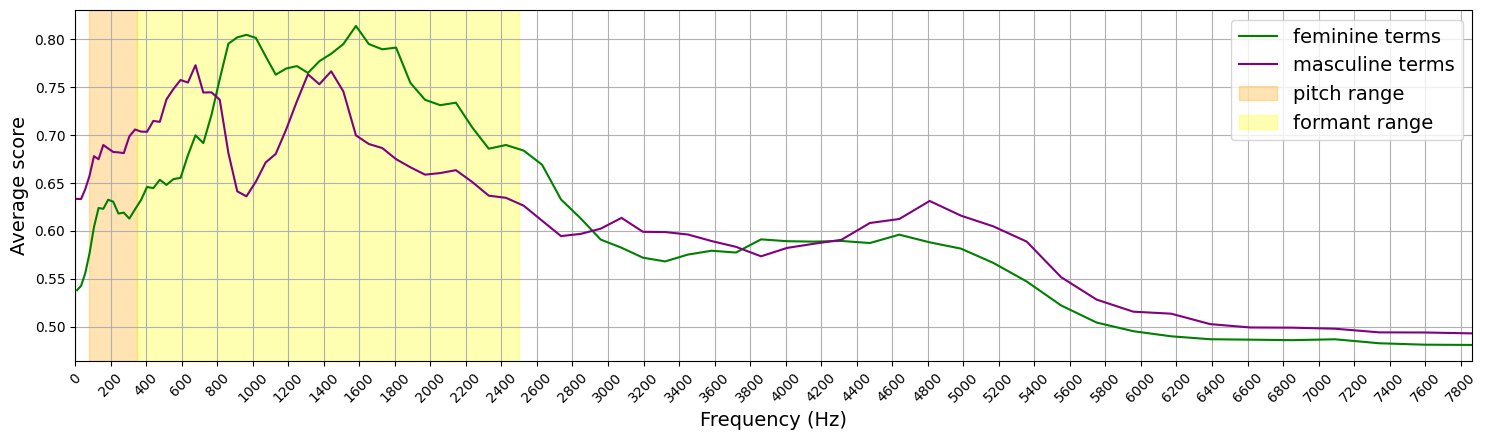

In [11]:
flip_idx_F = df[(df.category == '1F') & ~np.isnan(df.flip_percent)].index
flip_idx_M = df[(df.category == '1M') & ~np.isnan(df.flip_percent)].index

avg_score_F = np.nanmean(all_explanations.take(flip_idx_F, axis=0), axis=0)
avg_score_M = np.nanmean(all_explanations.take(flip_idx_M, axis=0), axis=0)

plt.figure(figsize=(15, 4.5))
plt.plot(frequency_axis, avg_score_F, color="green", label="feminine terms")
plt.plot(frequency_axis, avg_score_M, color="purple", label="masculine terms")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Average score", fontsize=14)
plt.xlim(0, frequency_axis[-1])
plt.xticks(ticks=np.arange(0, frequency_axis[-1] + 1, step=200), rotation=45)
plt.axvspan(80, 350, color='orange', alpha=0.3, label="pitch range")
plt.axvspan(350, 2500, color='yellow', alpha=0.3, label="formant range")
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## 3. Time Dimension – Word-Level Importance

Use Gentle forced-alignment timestamps to assign a saliency score to each source word
(max over the word's time frames and all frequency bins). Report the percentage of examples
where "I" or another self-referential word receives the highest score. Corresponds to Table 3
and Table 4.

In [12]:
def get_word_importance(sample_id: str, fbank_exp: np.ndarray) -> Dict[str, float]:
    """Return a saliency score for each source word using max-pooling over its time frames.

    Args:
        sample_id: Full sample ID (e.g. "it-0742_0"); the base utterance ID is derived
            by stripping the frame-range suffix before looking up the alignment file.
        fbank_exp: Attribution array of shape (T, F) for a single example.

    Returns:
        Mapping from word string to its max saliency score.
    """
    json_path = os.path.join(JSON_FOLDER, sample_id.split("_")[0])
    with open(json_path, 'r') as f:
        words = json.load(f)['words']

    word_to_score = {}
    for word_data in words:
        if word_data['case'] != 'success':
            continue
        # Gentle timestamps are in seconds; feature frame rate is ~100 fps
        start_frame = int(word_data['start'] * 100)
        end_frame = int(word_data['end'] * 100)

        if start_frame < end_frame:
            score = np.max(fbank_exp[start_frame:end_frame, :])
        else:
            # Zero-duration alignment: take the single frame
            score = np.max(fbank_exp[start_frame, :])

        word_to_score[word_data['word']] = score
    return word_to_score

In [13]:
top_words = [''] * len(df)

for index, row in df.iterrows():
    try:
        word_to_score = get_word_importance(
            row['id'],
            explanations[index]["fbank_heatmap"][0].numpy())

        max_score = max(word_to_score.values())
        for word, score in word_to_score.items():
            if score == max_score:
                if top_words[index] == '':
                    # Preserve capitalisation for "I" and contractions; lowercase everything else
                    top_words[index] = word if word[0] == 'I' else word.lower()
                else:
                    top_words[index] += ';' + word
    except FileNotFoundError:
        print(f"Warning: alignment file not found for {row['id']}")
        top_words[index] = 'N/A'

df['top_words'] = top_words

In [14]:
# Category 1 = speaker-referring terms; Art/Prep excluded following Savoldi et al. (2022b)
filtered_df = df[(df.cat_nb == 1) & (df.pos != 'Art/Prep')].copy()
print(f"{len(filtered_df)} examples after filtering")

357 examples after filtering


In [15]:
# Percentage of examples that flip, overall and by reference gender
flip_mask = ~np.isnan(filtered_df.flip_percent)
print(f"Flip rate (all):      {100 * flip_mask.sum() / len(filtered_df):.1f}% ({len(filtered_df)} examples)")

for gender in ['F', 'M']:
    sub = filtered_df[filtered_df.cat_gender == gender]
    n_flip = (~np.isnan(sub.flip_percent)).sum()
    print(f"Flip rate ({gender}):       {100 * n_flip / len(sub):.1f}% ({len(sub)} examples)")

Flip rate (all):      37.0% (357 examples)
Flip rate (F):       52.2% (182 examples)
Flip rate (M):       21.1% (175 examples)


### 3a. All Examples

In [16]:
# Percentage where "I" is the top-scoring word
print(round(filtered_df.top_words.str.startswith('I').mean() * 100, 2), "%")

33.33 %


In [17]:
# Percentage where any self-referential word is top-scoring
FIRST_PERSON_WORDS = {'I', "I'd", "I've", "I'm", "my", "My", 'me', 'myself'}

filtered_df['first_person_top_word'] = filtered_df['top_words'].apply(
    lambda x: any(w in FIRST_PERSON_WORDS for w in x.split(';')))
print(round(filtered_df['first_person_top_word'].mean() * 100, 2), "%")

42.02 %


### 3b. Flip Examples Only

In [18]:
filtered_flip_df = filtered_df[~np.isnan(filtered_df.flip_percent)].copy()
print(f"{len(filtered_flip_df)} flip examples")

132 flip examples


In [19]:
# Percentage where "I" is the top-scoring word
print(round(filtered_flip_df.top_words.str.startswith('I').mean() * 100, 2), "%")

46.21 %


In [20]:
# Percentage where any self-referential word is top-scoring
filtered_flip_df['first_person_top_word'] = filtered_flip_df['top_words'].apply(
    lambda x: any(w in FIRST_PERSON_WORDS for w in x.split(';')))
print(round(filtered_flip_df['first_person_top_word'].mean() * 100, 2), "%")

53.79 %


In [21]:
# Top-10 most frequently highlighted words (Table 4)
filtered_flip_df['top_words'].value_counts().head(10)

top_words
I       45
I'm      9
I've     5
me       4
and      3
was      3
grew     3
as       2
that     2
know     2
Name: count, dtype: int64